In [13]:
import collections
from IPython import display
import matplotlib.pyplot as plt
import io

import numpy as np
import torch
import copy
import itertools as itr
from scipy.special import softmax
from torch import nn
from common.ffn.ffn_relu import ParametricReLUNet
from common.coeff_calc.coeff_calc_ntk import NTKSimulator
from sklearn.metrics import mean_squared_error

from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from util import *
import logging

In [14]:
logging.basicConfig(filename="log_twostepsadaM1_minst_draft.log",
                level=logging.INFO,
                format='%(levelname)s: %(asctime)s %(message)s',
                datefmt='%m/%d/%Y %I:%M:%S')

In [15]:
# use it to conver from PIL to torch.Tensor
image_transform = ToTensor()

train_dataset = MNIST(root='./', train=True, download=True, transform=image_transform)
test_dataset = MNIST(root='./', train=False, download=True, transform=image_transform)

In [16]:
BATCH_SIZE_ADA = 512 #1024 #2048 #
BATCH_SIZE = 32

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE_ADA,
    shuffle=True,
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE
)

##### CONSTANTS

In [17]:
INPUT_DIM = 28 * 28
OUTPUT_DIM = 10  # num classes
INPUT_WIDTH, HIDDEN_WIDTH = 250, 100 #500, 200 #100, 50 # #
ADA_ROUNDS = 250
#ADA_ROUND_ERROR = 1 - 0.875

#lw = 7.5 - for BATCH_SIZE = 32
lb, lw = 1e-2, 7.5 #1e-2,1,1 #1e-2, 1e-2, 1
#lambdas as from (8.5)
lw_input, lw_hidden, lw_output = lw/INPUT_DIM, lw/INPUT_WIDTH, lw/HIDDEN_WIDTH

##### UTILS

In [18]:
def labels_to_logits(labels):
    batch_size = labels.shape[0]
    zz = np.full((OUTPUT_DIM, batch_size), -1.0)
    for batch_num in range(batch_size):
        zz[labels[batch_num], batch_num] = 1.0

    return zz

def visualise():
    # visualize all together
    display.clear_output()
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    axes[0].set_title('Loss (cross-entropy)')
    axes[0].plot(HISTORY_PARAMS['train_loss'], label='Train Loss')
    axes[0].plot(HISTORY_PARAMS['test_loss'], label='Test Loss')
    axes[0].grid()
    axes[0].legend(fontsize=20)
    
    axes[1].set_title('Accuracy')
    axes[1].plot(HISTORY_PARAMS['train_accuracy'], label='Train Accuracy')
    axes[1].plot(HISTORY_PARAMS['test_accuracy'], label='Test Accuracy')
    axes[1].grid()
    axes[1].legend(fontsize=20)
    
    plt.show()

HISTORY_PARAMS = collections.defaultdict(list)

In [19]:
def signMap_(num):
    return 1.0 if num > 0.0 else -1.0

signMap = np.vectorize(signMap_)

class MNISTReLU(ParametricReLUNet):
    def __init__(self, input_dim, output_dim):
        super().__init__(n0=input_dim,nk=0,nl=output_dim,l=0, bias_on=True)
        self.slope_positive = None
        self.slope_negative = None

        self.input_fc = nn.Linear(input_dim, INPUT_WIDTH)
        self.hidden_fc = nn.Linear(INPUT_WIDTH, HIDDEN_WIDTH)
        self.output_fc = nn.Linear(HIDDEN_WIDTH, output_dim)

    def set_slopes(self, slope_positive = 1.0, slope_negative = 0.25):
        super().set_slopes(slope_positive, slope_negative)
        self.slope_positive = slope_positive
        self.slope_negative = slope_negative        

    def forward_(self, x):
        return self.forward(x)

    def forward(self, x):
        #x = [batch size, height, width]
        #x = [batch size, height * width]
        h_1 = self.PReLU(self.input_fc(x))
        #h_1 = [batch size, INPUT_WIDTH]
        h_2 = self.PReLU(self.hidden_fc(h_1))
        #h_2 = [batch size, HIDDEN_WIDTH]
        y_pred = self.output_fc(h_2)
        #y_pred = [batch size, output dim]
        return y_pred
    
    #def forward_to_argmax_values(self, raw_logits):
        #raw_logits = self.forward_(x)
    #    return labels_to_logits(raw_logits.argmax(dim=-1))
    
    #def forward_to_sign_logits(self, x):
    #    raw_logits = np.transpose(self.forward_(x).detach().numpy())
    #    return signMap(raw_logits)
    
    def init_weights(self, cb=0.0, cw=1.0):
        logging.debug("FeedForwardNet weights initialisation with cb={}, cw={}".format(cb, cw))
        #Weight initialisation as in 2.19, 2.20
        self.cb, self.cw = cb, cw
        self.init_linear_weights(self.input_fc, self.bias_on, cb, cw/self.input_fc.in_features)
        self.init_linear_weights(self.hidden_fc, self.bias_on, cb, cw/self.hidden_fc.in_features)
        self.init_linear_weights(self.output_fc, self.bias_on, cb, cw/self.output_fc.in_features)

    def grad_zero(self):
        self.input_fc.weight.grad.zero_()
        self.input_fc.bias.grad.zero_()
        self.hidden_fc.weight.grad.zero_()
        self.hidden_fc.bias.grad.zero_()
        self.output_fc.weight.grad.zero_()
        self.output_fc.bias.grad.zero_()

    def clone(self):
        buffer = io.BytesIO()
        torch.save(self, buffer)
        buffer.seek(0) #<--- must see to origin every time before reading
        testNet = torch.load(buffer)
        del buffer
        return testNet


In [20]:
class NTKCalculator:
    def __init__(self):
        self.input_dweight = np.zeros((OUTPUT_DIM, BATCH_SIZE, INPUT_WIDTH, INPUT_DIM))
        self.input_dbias = np.zeros((OUTPUT_DIM, BATCH_SIZE, INPUT_WIDTH))
        self.hidden_dweight = np.zeros((OUTPUT_DIM, BATCH_SIZE, HIDDEN_WIDTH, INPUT_WIDTH))
        self.hidden_dbias = np.zeros((OUTPUT_DIM, BATCH_SIZE, HIDDEN_WIDTH))
        self.output_dweight = np.zeros((OUTPUT_DIM, BATCH_SIZE, OUTPUT_DIM, HIDDEN_WIDTH))
        self.output_dbias = np.zeros((OUTPUT_DIM, BATCH_SIZE, OUTPUT_DIM))

    def calculate_derivatives(self, testNet, logits):
        for kk, alpha in itr.product(range(OUTPUT_DIM), range(BATCH_SIZE)):
            df = torch.autograd.grad(logits[alpha,kk], (testNet.input_fc.weight, testNet.input_fc.bias\
                                            , testNet.hidden_fc.weight, testNet.hidden_fc.bias\
                                            , testNet.output_fc.weight, testNet.output_fc.bias)\
                , retain_graph=True, create_graph=True, allow_unused=True)
            self.input_dweight[kk, alpha] = df[0].detach().numpy()
            self.input_dbias[kk, alpha] = df[1].detach().numpy()
            self.hidden_dweight[kk, alpha] = df[2].detach().numpy()
            self.hidden_dbias[kk, alpha] = df[3].detach().numpy()
            self.output_dweight[kk, alpha] = df[4].detach().numpy()
            self.output_dbias[kk, alpha] = df[5].detach().numpy()

    def calculate_NTK(self):
        input_dweight_flat = np.reshape(self.input_dweight, (OUTPUT_DIM, BATCH_SIZE, INPUT_WIDTH * INPUT_DIM))
        hidden_dweight_flat = np.reshape(self.hidden_dweight, (OUTPUT_DIM, BATCH_SIZE, HIDDEN_WIDTH * INPUT_WIDTH))
        output_dweight_flat = np.reshape(self.output_dweight, (OUTPUT_DIM, BATCH_SIZE, OUTPUT_DIM * HIDDEN_WIDTH))

        input_dbias_sum = np.array([[[[ lb * (self.input_dbias[kk1, alpha1] @ self.input_dbias[kk2, alpha2])\
                                       for alpha1 in range(BATCH_SIZE)] for alpha2 in range(BATCH_SIZE)]\
                                        for kk1 in range(OUTPUT_DIM)] for kk2 in range(OUTPUT_DIM)])
        print("### input_dbias_sum")
        input_dweight_sum = np.array([[[[ lw_input * (input_dweight_flat[kk1, alpha1] @ input_dweight_flat[kk2, alpha2])\
                                       for alpha1 in range(BATCH_SIZE)] for alpha2 in range(BATCH_SIZE)]\
                                        for kk1 in range(OUTPUT_DIM)] for kk2 in range(OUTPUT_DIM)])
        print("### input_dweight_sum")
        
        hidden_dbias_sum = np.array([[[[ lb * (self.hidden_dbias[kk1, alpha1] @ self.hidden_dbias[kk2, alpha2])\
                                       for alpha1 in range(BATCH_SIZE)] for alpha2 in range(BATCH_SIZE)]\
                                        for kk1 in range(OUTPUT_DIM)] for kk2 in range(OUTPUT_DIM)])
        print("### hidden_dbias_sum")
        hidden_dweight_sum = np.array([[[[ lw_hidden * (hidden_dweight_flat[kk1, alpha1] @ hidden_dweight_flat[kk2, alpha2])\
                                       for alpha1 in range(BATCH_SIZE)] for alpha2 in range(BATCH_SIZE)]\
                                        for kk1 in range(OUTPUT_DIM)] for kk2 in range(OUTPUT_DIM)])
        print("### hidden_dweight_sum")
        
        output_dbias_sum = np.array([[[[ lb * (self.output_dbias[kk1, alpha1] @ self.output_dbias[kk2, alpha2])\
                                       for alpha1 in range(BATCH_SIZE)] for alpha2 in range(BATCH_SIZE)]\
                                        for kk1 in range(OUTPUT_DIM)] for kk2 in range(OUTPUT_DIM)])
        print("### output_dbias_sum")
        output_dweight_sum = np.array([[[[ lw_output * (output_dweight_flat[kk1, alpha1] @ output_dweight_flat[kk2, alpha2])\
                                       for alpha1 in range(BATCH_SIZE)] for alpha2 in range(BATCH_SIZE)]\
                                        for kk1 in range(OUTPUT_DIM)] for kk2 in range(OUTPUT_DIM)])
        print("### output_dweight_sum")
        
        return input_dbias_sum+input_dweight_sum+hidden_dbias_sum+hidden_dweight_sum+output_dbias_sum+output_dweight_sum

        '''
        HL = np.zeros((OUTPUT_DIM, OUTPUT_DIM, BATCH_SIZE, BATCH_SIZE))
        for kk1, kk2, alpha1, alpha2 in itr.product(range(OUTPUT_DIM), range(OUTPUT_DIM)\
                                                    , range(BATCH_SIZE), range(BATCH_SIZE)):
            if HL[kk1, kk2, alpha1, alpha2] == 0 or HL[kk2, kk1, alpha2, alpha1] == 0:
                val = lb * np.dot(self.input_dbias[kk1, alpha1], self.input_dbias[kk2, alpha2])
                val += lw_input * np.sum(np.multiply(self.input_dweight[kk1, alpha1], self.input_dweight[kk2, alpha2]))
                val += lb * np.dot(self.hidden_dbias[kk1, alpha1], self.hidden_dbias[kk2, alpha2])
                val += lw_hidden * np.sum(np.multiply(self.hidden_dweight[kk1, alpha1], self.hidden_dweight[kk2, alpha2]))
                val += lb * np.dot(self.output_dbias[kk1, alpha1], self.output_dbias[kk2, alpha2])
                val += lw_output * np.sum(np.multiply(self.output_dweight[kk1, alpha1], self.output_dweight[kk2, alpha2]))
                HL[kk1, kk2, alpha1, alpha2] = HL[kk2, kk1, alpha2, alpha1] = val
        
        return HL
        '''

class BigStepCalculator:

    def __init__(self, coeff_delta =0.1):
        self.delta_weight_00 = None
        self.delta_bias_00 = None
        self.delta_weight_01 = None
        self.delta_bias_01 = None
        self.delta_weight_02 = None
        self.delta_bias_02 = None
        self.coeff_delta = coeff_delta

    def do_step0(self, testNet, xx, yy, labels, delta):
        with torch.no_grad():
            testNet.input_fc.weight += torch.from_numpy(self.delta_weight_00) * delta
            testNet.input_fc.bias += torch.from_numpy(self.delta_bias_00) * delta
            testNet.hidden_fc.weight += torch.from_numpy(self.delta_weight_01) * delta
            testNet.hidden_fc.bias += torch.from_numpy(self.delta_bias_01) * delta
            testNet.output_fc.weight += torch.from_numpy(self.delta_weight_02) * delta
            testNet.output_fc.bias += torch.from_numpy(self.delta_bias_02) * delta
            logits_step0 = testNet.forward_(xx)
            prediction_step0 = logits_step0.argmax(dim=-1)
            zz0 = np.transpose(logits_step0.detach().numpy())

        accuracy_step0 = calculate_accuracy(prediction_step0, labels)
        mse_step0 = mean_squared_error(yy, zz0)
        return accuracy_step0, mse_step0, zz0

    def recalcFFN(self, testNet, images, labels, logits):
        xx = images.view(images.shape[0], -1)
        yy = labels_to_logits(labels) #true logits ∈ [-3, 3]
        zz = np.transpose(logits.detach().numpy()) #obtained logits

        print("#Calculating NTK for step 0")
        calc0 = NTKCalculator()
        calc0.calculate_derivatives(testNet, logits)
        print("##Calculating NTK by (8.4)")
        HL = calc0.calculate_NTK()
        print("##Calculating average and inverted")
        HL_avg = np.zeros((BATCH_SIZE, BATCH_SIZE))
        HL_delta = np.copy(HL)

        for alpha1, alpha2 in itr.product(range(BATCH_SIZE), range(BATCH_SIZE)):
            H_avg = np.average([HL[num, num, alpha1, alpha2] for num in np.arange(OUTPUT_DIM)])
            HL_avg[alpha1, alpha2] = H_avg
            for num in np.arange(OUTPUT_DIM):
                HL_delta[num, num, alpha1, alpha2] = HL[num, num, alpha1, alpha2] - H_avg

        HL_avg_top = np.linalg.inv(HL_avg)

        print("#Calculating Newton tensor by (∞.71), weights update by (∞.68) and checking accuracy")
        term0 = np.zeros((OUTPUT_DIM, OUTPUT_DIM, BATCH_SIZE, BATCH_SIZE))
        for alpha1, alpha2 in itr.product(range(BATCH_SIZE), range(BATCH_SIZE)):
            for num in range(OUTPUT_DIM):
                term0[num, num, alpha1, alpha2] = HL_avg_top[alpha1, alpha2]

        term1a = np.tensordot(np.tensordot(HL_avg_top, HL_delta, axes=((1),(2))), HL_avg_top, axes=((3),(0)))
        term1 = np.transpose(term1a, (1,2,0,3))

        term2a = term1a #np.tensordot(HL_avg_top, HL_delta, axes=((1),(2)))
        term2b = np.tensordot(np.tensordot(term2a, HL_delta, axes=((2,3),(0,2))), HL_avg_top, axes=((3),(0)))
        term2 = np.transpose(term2b, (1,2,0,3))

        eta_kappa = term0 - term1 + term2; #(∞.71)

        #print("!!{}-{}".format(eta_kappa.shape, (zz - yy).shape))
        term = -1*np.tensordot(eta_kappa, (zz - yy), axes=((1,3),(0,1)))
        self.delta_weight_00 = np.tensordot(term, calc0.input_dweight, axes=((0,1),(0,1))) * lw_input #(∞.68)
        self.delta_bias_00 = np.tensordot(term, calc0.input_dbias, axes=((0,1),(0,1))) * lb #(∞.68)
        self.delta_weight_01 = np.tensordot(term, calc0.hidden_dweight, axes=((0,1),(0,1))) * lw_hidden #(∞.68)
        self.delta_bias_01 = np.tensordot(term, calc0.hidden_dbias, axes=((0,1),(0,1))) * lb #(∞.68)
        self.delta_weight_02 = np.tensordot(term, calc0.output_dweight, axes=((0,1),(0,1))) * lw_output #(∞.68)
        self.delta_bias_02 = np.tensordot(term, calc0.output_dbias, axes=((0,1),(0,1))) * lb #(∞.68)

        accuracy_prev = calculate_accuracy(logits.argmax(dim=-1), labels)
        mse_prev = mean_squared_error(yy, zz)
        coeff_abs = 0.0
        while (round(coeff_abs, 1)) < 1.0:
            coeff_abs += self.coeff_delta
            accuracy_step0, mse_step0, _ = self.do_step0(testNet, xx, yy, labels, self.coeff_delta)
            if (accuracy_step0 < accuracy_prev or (accuracy_step0 > 0.5 and mse_step0 >= mse_prev)):
                coeff_abs -= self.coeff_delta
                accuracy_step0, mse_step0, _ = self.do_step0(testNet, xx, yy, labels, -self.coeff_delta)
                break;
                
            accuracy_prev, mse_prev = accuracy_step0, mse_step0

        return coeff_abs, accuracy_step0, mse_step0, HL, calc0
            
class SmallStepCalculator:

    def __init__(self, coeff_delta =0.1):
        self.delta_weight_10 = None
        self.delta_bias_10 = None
        self.delta_weight_11 = None
        self.delta_bias_11 = None
        self.delta_weight_12 = None
        self.delta_bias_12 = None
        self.coeff_delta = coeff_delta

    def do_step1(self, testNet, xx, yy, labels, delta):
        with torch.no_grad():
            testNet.input_fc.weight += torch.from_numpy(self.delta_weight_10) * delta
            testNet.input_fc.bias += torch.from_numpy(self.delta_bias_10) * delta
            testNet.hidden_fc.weight += torch.from_numpy(self.delta_weight_11) * delta
            testNet.hidden_fc.bias += torch.from_numpy(self.delta_bias_11) * delta
            testNet.output_fc.weight += torch.from_numpy(self.delta_weight_12) * delta
            testNet.output_fc.bias += torch.from_numpy(self.delta_bias_12) * delta
            logits_step1 = testNet.forward_(xx)
            prediction_step1 = logits_step1.argmax(dim=-1)
            zz1 = np.transpose(logits_step1.detach().numpy())

        accuracy_step1 = calculate_accuracy(prediction_step1, labels)
        mse_step1 = mean_squared_error(yy, zz1)
        return accuracy_step1, mse_step1, zz1

    def recalcFFN(self, testNet, images, labels, logits1, accuracy_step0, mse_step0): #, HL0, calc0):
        xx = images.view(images.shape[0], -1)
        yy = labels_to_logits(labels) #true logits ∈ [-1, 1]        
        zz1 = np.transpose(logits1.detach().numpy())
        calc1 = NTKCalculator()
        calc1.calculate_derivatives(testNet, logits1)
        print("##Calculating NTK by (8.4)")
        '''Is new ntk required?'''
        HL1 = calc1.calculate_NTK()
        #calc1 = calc0
        #HL1 = HL0

        print("##Calculating average and inverted")
        HL1_avg = np.zeros((BATCH_SIZE, BATCH_SIZE))
        #HL_delta = np.copy(HL)

        for alpha1, alpha2 in itr.product(range(BATCH_SIZE), range(BATCH_SIZE)):
            H1_avg = np.average([HL1[num, num, alpha1, alpha2] for num in np.arange(OUTPUT_DIM)])
            HL1_avg[alpha1, alpha2] = H1_avg

        HL1_avg_top = np.linalg.inv(HL1_avg)
        

        print("##Small step calculation")
        term0 = -1*np.matmul((zz1 - yy), HL1_avg_top)
        self.delta_weight_10 = np.tensordot(term0, calc1.input_dweight, axes=([0,1],[0,1])) * lw_input
        self.delta_bias_10 = np.tensordot(term0, calc1.input_dbias, axes=([0,1],[0,1])) * lb
        self.delta_weight_11 = np.tensordot(term0, calc1.hidden_dweight, axes=([0,1],[0,1])) * lw_hidden
        self.delta_bias_11 = np.tensordot(term0, calc1.hidden_dbias, axes=([0,1],[0,1])) * lb
        self.delta_weight_12 = np.tensordot(term0, calc1.output_dweight, axes=([0,1],[0,1])) * lw_output
        self.delta_bias_12 = np.tensordot(term0, calc1.output_dbias, axes=([0,1],[0,1])) * lb
        #Step forward
        accuracy_prev, mse_prev = accuracy_step0, mse_step0
        coeff_abs = 0.0
        while (round(coeff_abs, 1)) < 1.0:
            coeff_abs += self.coeff_delta
            #do_step1(self, testNet, xx, yy, labels, delta):
            accuracy_step1, mse_step1, _ = self.do_step1(testNet, xx, yy, labels, self.coeff_delta)
            if (accuracy_step1 < accuracy_prev or mse_step1 >= mse_prev):
                coeff_abs -= self.coeff_delta
                accuracy_step1, mse_step1, _ = self.do_step1(testNet, xx, yy, labels, -self.coeff_delta)
                break;
                
            accuracy_prev, mse_prev = accuracy_step1, mse_step1

        return coeff_abs, accuracy_step1, mse_step1

def twoStepsIter(testNet, images, labels, iteration_num, recalc_step1 = True):
    stepCalc0, stepCalc1 = BigStepCalculator(), SmallStepCalculator()
    yy = labels_to_logits(labels) #true logits ∈ [-1, 1]
    #images = [batch_size, height, width]
    batch_size = images.shape[0]
    xx = images.view(batch_size, -1)
    testNet.grad_zero
    logits = testNet.forward_(xx)
    zz = np.transpose(logits.detach().numpy()) #obtained logits

    prediction_beforesteps = logits.argmax(dim=-1)
    accuracy_beforesteps = calculate_accuracy(prediction_beforesteps, labels)
    mse_beforesteps = mean_squared_error(yy, zz)
    logging.info("Before steps iter {}: accuracy={}, MSE={}".format(iteration_num, accuracy_beforesteps, mse_beforesteps))

    coeff_abs, accuracy_step0, mse_step0, HL0, calc0 = stepCalc0.recalcFFN(testNet, images, labels, logits)
    logging.info("After step0 iter {}, coeff_abs {}: accuracy={}, MSE={}"\
                 .format(iteration_num, coeff_abs, accuracy_step0, mse_step0))
    
    if (accuracy_step0 < 1.0 or recalc_step1 == True):
        print("##Calculating NTK for step 1")
        testNet.grad_zero
        logits1 = testNet.forward_(xx)
        #zz1 = np.transpose(logits1.detach().numpy())

        coeff_abs1, accuracy_step1, mse_step1 = \
            stepCalc1.recalcFFN(testNet, images, labels, logits1, accuracy_step0, mse_step0) #, HL0, calc0)
        logging.info("After step1 iter {}, coeff_abs {}: accuracy={}, MSE={}"\
                    .format(iteration_num, coeff_abs1, accuracy_step1, mse_step1))

        return accuracy_step1, mse_step1
    else:
        return accuracy_step0, mse_step0


In [21]:
def errorMap_(num):
    return 1.0 if num == -1.0 else 0

errorMap = np.vectorize(errorMap_)

class AdaBoostM1:
    def __init__(self, test_array, true_test_labels):
        self.initData(test_array, true_test_labels)
        self.funcs = []
        self.coefs = []

    def initData(self, test_array, true_test_labels):
        self.test_array = test_array
        self.true_labels = true_test_labels
        self.data_size = test_array.shape[0]
        self.DD = np.full((self.data_size), 1/(self.data_size))

    def addFuncCoef(self, func, coef):
        self.funcs.append(func)
        self.coefs.append(coef)

    def getMatches(self, func):
        with torch.no_grad():
            calculated_labels = func.forward_(self.test_array).argmax(dim=-1).detach().numpy()
        #logging.info("getMatches: calculated_labels {}, true_labels {}".format(calculated_labels, self.true_labels))
        return np.where((self.true_labels == calculated_labels), 1, -1) #self.true_labels * calculated_labels

    def getError(self, func):
        return self.DD * errorMap(self.getMatches(func))

    def getResult(self, xx):
        batch_size = xx.shape[0]
        zz_argmax = np.full((OUTPUT_DIM, batch_size), 0.0)
        zz_logits = np.zeros_like(zz_argmax)
        with torch.no_grad():
            for ii in range(len(self.funcs)):
                raw_logits = self.funcs[ii].forward_(xx)
                zz_argmax += self.coefs[ii] * labels_to_logits(raw_logits.argmax(dim=-1))
                zz_logits += self.coefs[ii] * np.transpose(raw_logits.detach().numpy())
                 #self.funcs[ii].forward_to_argmax_values(xx)
        return zz_argmax.argmax(0), zz_logits

'''    
    def getLogitsWeighted(self, xx):
        batch_size = xx.shape[0]
        zz = np.full((OUTPUT_DIM, batch_size), 0.0)
        with torch.no_grad():
            for ii in range(len(self.funcs)):
                zz += self.coefs[ii] * np.transpose(self.funcs[ii].forward_(xx).detach().numpy())
        return zz
'''

'    \n    def getLogitsWeighted(self, xx):\n        batch_size = xx.shape[0]\n        zz = np.full((OUTPUT_DIM, batch_size), 0.0)\n        with torch.no_grad():\n            for ii in range(len(self.funcs)):\n                zz += self.coefs[ii] * np.transpose(self.funcs[ii].forward_(xx).detach().numpy())\n        return zz\n'

In [22]:
#ADA_ROUND_ERRORS = [0.125, 0.125, 0.15, 0.175, 0.2, 0.23, 0.26, 0.3, 0.35, 0.4, 0.45, 0.5]
ADA_ROUND_ERRORS = [0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.5, 0.5]

def decrease_classifier_error(adaBoost, testNext, images, labels, iteration_num, recalc_step1 = True):
    #delta, ffn_iter = 0.00625, 0
    accuracy_iter = 0.0
    for error_threshold in ADA_ROUND_ERRORS:
        #error_threshold = ADA_ROUND_ERROR + delta*ffn_iter
        #ffn_iter += 1
        logging.info("On iter {} error_threshold set to {}".format(iteration_num, error_threshold))
        errorArray = adaBoost.getError(testNext)
        error_by_point = -errorArray #np.sum(errorArray, (0))
        error = np.sum(errorArray)
        if error < error_threshold :
            logging.info("On iter {} classifier with a small error found with ADA-error: {}".format(iteration_num, error))
            break
        else:
            logging.info("On iter {} classifier with a small error searching with initial ADA-error: {}"\
                         .format(iteration_num, error))
            indices = np.argsort(error_by_point)[0:BATCH_SIZE]
            logging.info("Worst points selected: {}".format(indices))
            sub_images, sub_labels = images[indices], labels[indices]
            accuracy_iter, _ = twoStepsIter(testNext, sub_images, sub_labels, iteration_num, recalc_step1)
            #if accuracy_iter >= 1.0:
            #    break
    return error, accuracy_iter

##### SUBSET FETCH AND FFN initialisation

In [23]:
train_iter = iter(train_dataloader)
images, labels = next(train_iter)
xx = images.view(images.shape[0], -1)
yy = labels.detach().numpy() #labels_to_logits(labels) #true logits ∈ [-1, 1]
adaBoost = AdaBoostM1(xx, yy)

#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.0
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

testNet = MNISTReLU(INPUT_DIM, OUTPUT_DIM)
testNet.set_log_level("info")
testNet.set_slopes(slope_plus, slope_minus)
testNet.init_weights(cb, cw)

logging.info("Initial learning on subset of size {}".format(BATCH_SIZE))
WARMUP_CYCLES = 4
for warmup_cycle in range(WARMUP_CYCLES):
    print("warmup_cycle:", warmup_cycle)
    accuracy_train, mse_train = twoStepsIter(testNet, images[warmup_cycle*BATCH_SIZE:(warmup_cycle+1)*BATCH_SIZE]\
                                             , labels[warmup_cycle*BATCH_SIZE:(warmup_cycle+1)*BATCH_SIZE], -1)
logging.info("On warmup_cycle {} accuracy_train = {}, mse_train = {}".format(warmup_cycle, accuracy_train, mse_train))
#error, _ = decrease_classifier_error(adaBoost, testNet, images, labels, -1)
#logging.info("Initial ADA-error: {}".format(error))


FeedForwardNet created with n0=784, nk=0, nl=10, l=0, bias_on=True
warmup_cycle: 0
#Calculating NTK for step 0
##Calculating NTK by (8.4)
### input_dbias_sum
### input_dweight_sum
### hidden_dbias_sum
### hidden_dweight_sum
### output_dbias_sum
### output_dweight_sum
##Calculating average and inverted
#Calculating Newton tensor by (∞.71), weights update by (∞.68) and checking accuracy
##Calculating NTK for step 1
##Calculating NTK by (8.4)
### input_dbias_sum
### input_dweight_sum
### hidden_dbias_sum
### hidden_dweight_sum
### output_dbias_sum
### output_dweight_sum
##Calculating average and inverted
##Small step calculation
warmup_cycle: 1
#Calculating NTK for step 0
##Calculating NTK by (8.4)
### input_dbias_sum
### input_dweight_sum
### hidden_dbias_sum
### hidden_dweight_sum
### output_dbias_sum
### output_dweight_sum
##Calculating average and inverted
#Calculating Newton tensor by (∞.71), weights update by (∞.68) and checking accuracy
##Calculating NTK for step 1
##Calculating NT

##### ADABOOST LOOP STARTS HERE

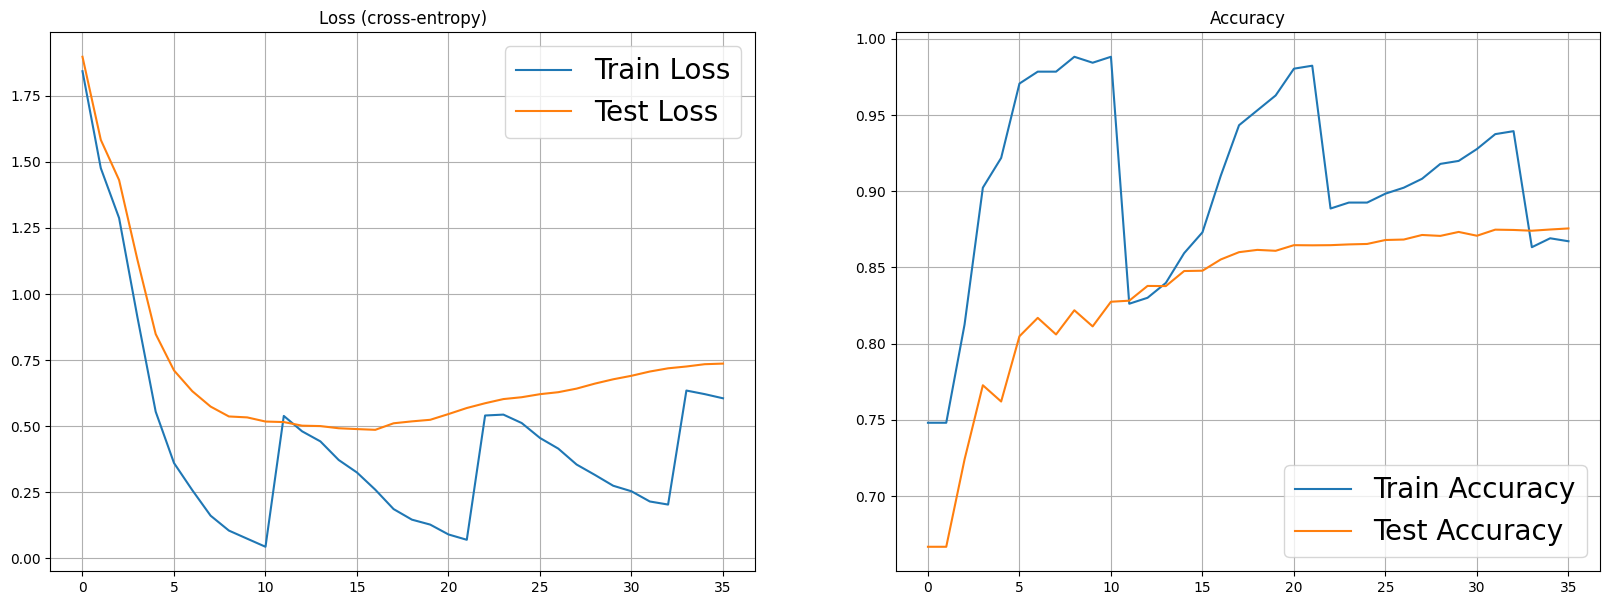

#Calculating NTK for step 0
##Calculating NTK by (8.4)
### input_dbias_sum
### input_dweight_sum
### hidden_dbias_sum
### hidden_dweight_sum
### output_dbias_sum
### output_dweight_sum
##Calculating average and inverted
#Calculating Newton tensor by (∞.71), weights update by (∞.68) and checking accuracy
##Calculating NTK for step 1
##Calculating NTK by (8.4)
### input_dbias_sum
### input_dweight_sum
### hidden_dbias_sum
### hidden_dweight_sum
### output_dbias_sum
### output_dweight_sum
##Calculating average and inverted
##Small step calculation
#Calculating NTK for step 0
##Calculating NTK by (8.4)
### input_dbias_sum
### input_dweight_sum
### hidden_dbias_sum
### hidden_dweight_sum
### output_dbias_sum
### output_dweight_sum
##Calculating average and inverted
#Calculating Newton tensor by (∞.71), weights update by (∞.68) and checking accuracy
##Calculating NTK for step 1
##Calculating NTK by (8.4)
### input_dbias_sum


In [24]:
def loss_crossentropy(zz_logits, true_labels):
    qq = softmax(zz_logits, axis=(0))
    #pp_raw = true_labels.detach().numpy()
    pp = np.zeros_like(qq)
    for col in range(len(true_labels)):
        pp[true_labels[col],col]=1
    return -np.sum(pp * np.log(qq))/len(true_labels)

#mm, kk = BATCH_SIZE_ADA, OUTPUT_DIM
iteration_num, iteration_reset = 0, 0

#preserving innitial FFN
testNext = testNet
#Ada-boost cycle
while iteration_num < ADA_ROUNDS:
    test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter()

    #Сlassifier with a small error retrieval
    testNext = testNext.clone()
    #Last param False-to skip 2-nd step recalc
    error, accuracy_iter = decrease_classifier_error(adaBoost, testNext, images, labels, iteration_num, True) 
    alpha = 0.5*np.log((1-error)/error)
    #norm_factor = 2*(error*(1-error))**0.5
    adaBoost.DD = adaBoost.DD * (np.exp(-alpha*adaBoost.getMatches(testNext)))
    adaBoost.DD = adaBoost.DD/np.sum(adaBoost.DD)
    logging.info("On iter {} adding classifier with alpha={} ".format(iteration_num, alpha))
    adaBoost.addFuncCoef(testNext, alpha)

    #empirical params
    zz, zz_logits = adaBoost.getResult(xx)
    accuracy_train = calculate_accuracy_np(zz, labels.detach().numpy())
    crossentropy_train = loss_crossentropy(zz_logits, labels)
    #F_train = np.average(np.exp(-1 * yy * labels_to_logits(zz)))
    # save average train loss and accuracy
    HISTORY_PARAMS['train_loss'].append(crossentropy_train)
    HISTORY_PARAMS['train_accuracy'].append(accuracy_train)

    #generalisation params
    for test_images, test_labels in test_dataloader:
        test_batch_size = test_images.shape[0]
        test_xx = test_images.view(test_batch_size, -1)
        #with torch.no_grad():
        test_prediction, test_logits = adaBoost.getResult(test_xx)
        #test_prediction = test_logits.argmax(0)

        #mean_squared_error(labels_to_logits(test_labels), test_logits)
        #F_test = np.average(np.exp(-1 * labels_to_logits(test_labels) * labels_to_logits(test_prediction)))
        crossentropy_test = loss_crossentropy(test_logits, test_labels)
        test_loss_meter.update(crossentropy_test)
        test_accuracy_meter.update(calculate_accuracy_np(test_prediction, test_labels.detach().numpy()))
    # save average test accuracy loss and accuracy
    HISTORY_PARAMS['test_loss'].append(test_loss_meter.avg)
    HISTORY_PARAMS['test_accuracy'].append(test_accuracy_meter.avg)
    
    visualise()

    logging.info("On iter {} accuracy_train={}".format(iteration_num, accuracy_train))

    if (error < 0.01 or accuracy_train >= 1.0 or (iteration_reset >= 10)):
        logging.info("On iter {} with ADA-error={} and accuracy_iter={} re-reading sample data"\
                     .format(iteration_num, error, accuracy_iter))
        images, labels = next(train_iter)
        xx = images.view(images.shape[0], -1)
        yy = labels.detach().numpy() #labels_to_logits(labels) #true logits ∈ [-1, 1]
        adaBoost.initData(xx, yy)
        iteration_reset = 0
        testNext = testNet
    elif (error > 0.5):
        raise Exception("On iter {} error {} exceeds 0.5, alg is terminated".format(iteration_num, error))
    else:
        iteration_reset += 1

    iteration_num += 1


In [ ]:
testtest_accuracy_meter = AverageMeter()
for test_images, test_labels in test_dataloader:
    test_batch_size = test_images.shape[0]
    test_xx = test_images.view(test_batch_size, -1)
    #with torch.no_grad():
    test_logits = adaBoost.getResult(test_xx)
    test_prediction = test_logits.argmax(0)

    #test_loss_meter.update(mean_squared_error(labels_to_logits(test_labels), test_logits))
    testtest_accuracy_meter.update(calculate_accuracy_np(test_prediction, test_labels.detach().numpy()))

In [ ]:
print(testtest_accuracy_meter.avg)

0.07286682615629984


In [ ]:
abc_accuracy_meter = AverageMeter()
abc = adaBoost.funcs[50]
for test_images, test_labels in test_dataloader:
    test_batch_size = test_images.shape[0]
    test_xx = test_images.view(test_batch_size, -1)
    with torch.no_grad():
        test_logits = abc.forward_(test_xx)
        test_prediction = test_logits.argmax(dim=-1)

    #test_loss_meter.update(mean_squared_error\
    #                        (np.transpose(test_logits.detach().numpy()), labels_to_logits(test_labels)))
    #zz0 = np.transpose(logits_step0.detach().numpy())
    abc_accuracy_meter.update(calculate_accuracy(test_prediction, test_labels))

print(abc_accuracy_meter.avg)

0.7292663477824636
